# Ficha de Avaliação – UFCD 10810

**Fundamentos do Desenvolvimento de Modelos Analíticos em Python**

**Objetivo**:  Avaliar  a  aplicação  de  conhecimentos  em  modelos  analíticos  supervisionados  e  não  supervisionados, com base em datasets reais e públicos.


Os Exercícios 1 e 2 são totalmente orientados, pelo que bastará reproduzir o código. Se quiseres podes acrescentar melhorias.

No final são apresentados dois exercícios que deverás resolver autonomamente.

**Por fim, anexa todos os ficheiros ou ficheiro obtidos na resolução desta Ficha à secção correspondente no moodle.**

---

# Exercício 1 – Clustering com K-Means (Modelo Não Supervisionado)
(5 valores)

Faz o download do dataset  em https://www.kaggle.com/datasets/abdallahwagih/mall-customers-segmentation 

**Contexto**:
Pretende-se segmentar clientes de um centro comercial com base nas suas características de consumo, para apoiar ações de marketing direcionado. 

**Passos obrigatórios**:
1. Carregar e explorar os dados (verificar colunas e tipos). 
2. Aplicar pré-processamento: 
    a. Tratar valores ausentes, se existirem. 
    b. Normalizar as colunas numéricas. 
    c. Codificar variáveis categóricas com OneHotEncoder, se necessário. 
3. Determinar o número ideal de clusters usando o **Modelo do Cotovelo**. 
4. Aplicar **K-Means** com o número ótimo de clusters. 
5. Avaliar o clustering com o **Coeficiente de Silhueta**. 
6. Visualizar os clusters em 2D com **PCA**.
7. Interpretar os grupos formados (ex: características dos clientes por grupo)

In [1]:
# exercicio1_kmeans_mall.py

import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder 
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score 
from sklearn.decomposition import PCA 
import matplotlib.pyplot as plt

In [5]:
# 1. Carregar dados 
df = pd.read_csv("data/Mall_Customers.csv")
print(df.info())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [6]:
# 2. Pré-processamento 
# Verificar e remover colunas não numéricas ou pouco informativas 
df = df.drop("CustomerID", axis=1) 

In [7]:
# One-hot encoding da coluna 'Genre' 
df = pd.get_dummies(df, columns=["Genre"], drop_first=True)

In [8]:
# Normalização
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

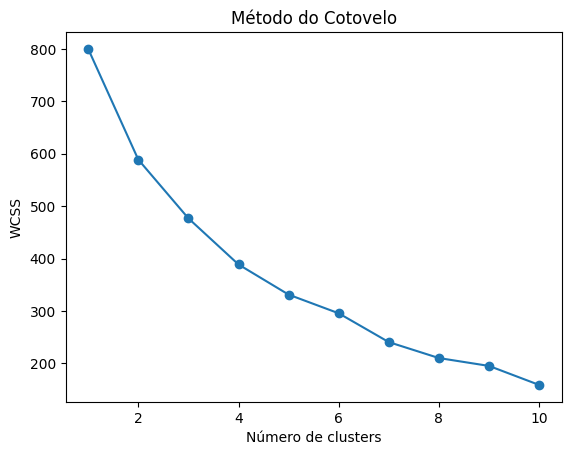

In [9]:
# 3. Modelo do Cotovelo 
wcss = [] 
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o') 
plt.title("Método do Cotovelo") 
plt.xlabel("Número de clusters") 
plt.ylabel("WCSS") 
plt.show()

In [10]:
# 4. Aplicar KMeans com k=5 (por exemplo)
k = 5 
kmeans = KMeans(n_clusters=k, random_state=0) 
clusters = kmeans.fit_predict(scaled_data)

In [11]:
# 5. Avaliar com coeficiente de silhueta
score = silhouette_score(scaled_data, clusters)
print(f"Coeficiente de Silhueta: {score:.2f}") 

Coeficiente de Silhueta: 0.32


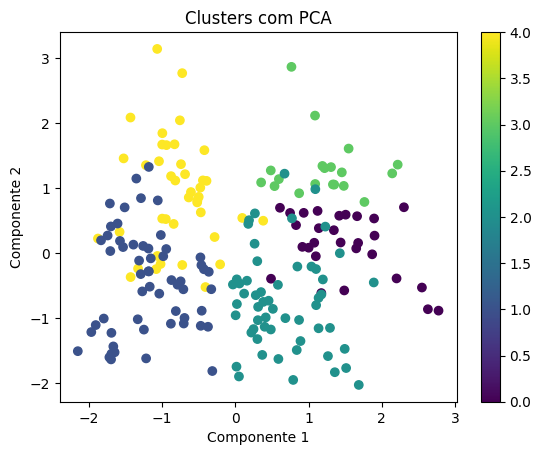

In [12]:
# 6. Visualizar com PCA
pca = PCA(n_components=2) 
pca_data = pca.fit_transform(scaled_data)  

plt.scatter(pca_data[:, 0], pca_data[:, 1], c=clusters, cmap='viridis') 
plt.title("Clusters com PCA") 
plt.xlabel("Componente 1") 
plt.ylabel("Componente 2") 
plt.colorbar() 
plt.show()

---